
--- 1. Carregamento dos Dados ---

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tentando carregar '/content/drive/MyDrive/Mestrado Cesar/Base de Dados/Kaggle/paysim.csv'...
Arquivo carregado com sucesso!
Formato do dataset (Linhas, Colunas): (6362620, 11)
--------------------------------------------------

--- 2. Limpeza de Colunas e Tratamento ---

As colunas ['nameOrig', 'nameDest', 'isFlaggedFraud', 'step'] foram removidas para evitar ruído.

--- 3. Criação de Novas Variáveis (Engenharia de Features) ---

Variáveis 'amount_log', 'errorBalanceOrig' e 'errorBalanceDest' criadas com sucesso.
--------------------------------------------------

--- 4. Preparando Dados para Machine Learning ---

Filtrando transações apenas para TRANSFER e CASH_OUT (Foco em fraudes reais)...
Dados divididos! Treino: 2216327 linhas, Teste: 554082 linhas.
Aplicando RobustScaler para normalizar as grandezas numéricas...

--- 

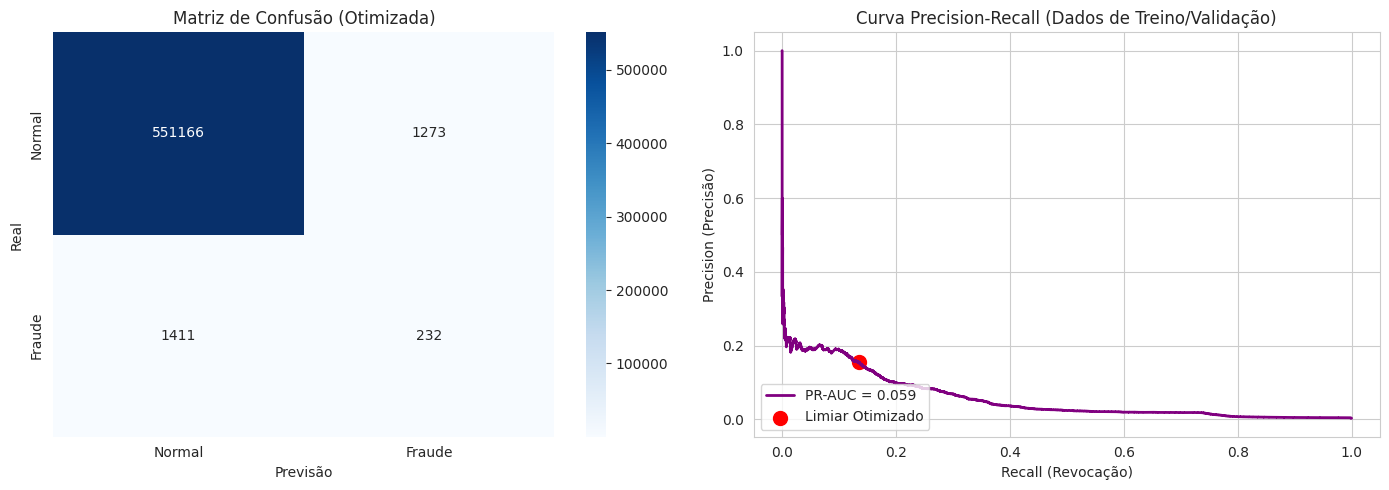


Fim do processamento. Métricas aprimoradas aplicadas com sucesso!


In [1]:
# -*- coding: utf-8 -*-
"""
Script Otimizado para preparação e análise do dataset PaySim1 (Detecção de Fraude).
Base de dados: https://www.kaggle.com/datasets/ealaxi/paysim1
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve)

# Configurações de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("\n--- 1. Carregamento dos Dados ---\n")
try:
    from google.colab import drive
    drive.mount('/content/drive')

    caminho_csv = '/content/drive/MyDrive/Mestrado Cesar/Base de Dados/Kaggle/paysim.csv'
    print(f"Tentando carregar '{caminho_csv}'...")
    df = pd.read_csv(caminho_csv)
    print("Arquivo carregado com sucesso!")
    print(f"Formato do dataset (Linhas, Colunas): {df.shape}")
    print("-" * 50)
except FileNotFoundError:
    print(f"Erro: O arquivo '{caminho_csv}' não foi encontrado.")
    print("Verifique se o caminho no Google Drive está correto e se você deu permissão de acesso.")
    exit()

print("\n--- 2. Limpeza de Colunas e Tratamento ---\n")

# Justificativa da remoção:
# nameOrig/nameDest: Identificadores que não generalizam.
# isFlaggedFraud: Regra de negócio fixa.
# step: Causa ruído em modelos de anomalia (Isolation Forest) pois cresce linearmente.
colunas_para_remover = ['nameOrig', 'nameDest', 'isFlaggedFraud', 'step']
df = df.drop(columns=[col for col in colunas_para_remover if col in df.columns])

print(f"As colunas {colunas_para_remover} foram removidas para evitar ruído.")

# Tratamento de Nulos crítico para ML
if df.isnull().sum().sum() > 0:
    df = df.dropna(subset=['isFraud']) # Remove linhas sem a variável alvo
    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\n--- 3. Criação de Novas Variáveis (Engenharia de Features) ---\n")

# 1. amount_log: Suaviza a variação extrema dos valores de transação
df['amount_log'] = np.log1p(df['amount'])

# 2. errorBalanceOrig: Detecta se a conta de origem ficou com saldo inconsistente
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# 3. errorBalanceDest: Detecta se a conta de destino ficou com saldo inconsistente
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Como já temos amount_log, podemos remover o amount bruto para diminuir a multicolinearidade
df = df.drop(columns=['amount'])

print("Variáveis 'amount_log', 'errorBalanceOrig' e 'errorBalanceDest' criadas com sucesso.")
print("-" * 50)

print("\n--- 4. Preparando Dados para Machine Learning ---\n")

# EDA nos revelou que fraudes ocorrem apenas nestes dois tipos:
print("Filtrando transações apenas para TRANSFER e CASH_OUT (Foco em fraudes reais)...")
df_filtrado = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Transformando a coluna categórica 'type' em numérica (One-Hot)
df_ml = pd.get_dummies(df_filtrado, columns=['type'], drop_first=True)

# Separando X (Features) e y (Alvo)
X = df_ml.drop(columns=['isFraud'])
y = df_ml['isFraud']

# Dividindo Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Dados divididos! Treino: {X_train.shape[0]} linhas, Teste: {X_test.shape[0]} linhas.")

# Escalonamento Robusto: Vital para o Isolation Forest não dar peso excessivo a saldos gigantes
print("Aplicando RobustScaler para normalizar as grandezas numéricas...")
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertendo de volta para DataFrame por praticidade
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\n--- 5. Simulação de Aprendizado Federado (FL) ---\n")

NUM_CLIENTES = 3
print(f"Simulando ambiente com {NUM_CLIENTES} clientes (silos de dados).")

# Divisão dos dados de treino entre os "clientes"
tamanho_chunk = len(X_train) // NUM_CLIENTES
clientes_X = [X_train.iloc[i * tamanho_chunk : (i + 1) * tamanho_chunk] for i in range(NUM_CLIENTES)]

modelos_locais = []
tempos_treinamento = []

print("\nIniciando Treinamento Local (Isolation Forest) nos clientes...")
for i in range(NUM_CLIENTES):
    inicio_treino = time.time()

    # IsolationForest OTIMIZADO:
    # Contaminação 'auto' permite que a floresta foque na estrutura dos dados,
    # em vez de forçar um número fixo de anomalias precocemente.
    modelo_local = IsolationForest(
        n_estimators=150,
        max_samples=0.8,
        contamination='auto',
        n_jobs=-1,
        random_state=42+i
    )

    modelo_local.fit(clientes_X[i])
    fim_treino = time.time()

    modelos_locais.append(modelo_local)
    tempos_treinamento.append(fim_treino - inicio_treino)
    print(f"-> Cliente {i+1} treinado em {fim_treino - inicio_treino:.2f} segundos.")

print("\n--- 6. Agregação Federada e Otimização de Limiar ---")

class ModeloFederado:
    def __init__(self, modelos_locais):
        self.modelos_locais = modelos_locais

    def decision_function(self, X):
        # Média dos escores de anomalia de todos os clientes locais
        escores = np.zeros(X.shape[0])
        for modelo in self.modelos_locais:
            escores += modelo.decision_function(X)
        return escores / len(self.modelos_locais)

modelo_global = ModeloFederado(modelos_locais)

# ESTRATÉGIA OTIMIZADA: Encontrar o melhor limiar de corte no TREINO usando curva PR
print("\nOtimizando o limiar de decisão via Curva Precision-Recall no conjunto de validação...")
# Invertemos o sinal: Valores MAIORES = maior probabilidade de fraude
y_scores_train = -modelo_global.decision_function(X_train)

# Calculando precisão e recall para vários limiares possíveis
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores_train)

# Calculando F1-Score para cada limiar (evitando divisão por zero)
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls),
                      out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

# O melhor limiar é aquele que maximiza o F1-Score
melhor_indice = np.argmax(f1_scores)
limiar_otimizado = thresholds[melhor_indice]
print(f"Limiar matemático otimizado (F1 Máximo): {limiar_otimizado:.4f}")

print("\n--- 7. Inferência no Servidor Global (Teste Real) ---")
inicio_inferencia = time.time()

# Aplicando os escores na base de TESTE
y_scores_test = -modelo_global.decision_function(X_test)

# Classificando baseado no limiar otimizado
y_pred = (y_scores_test >= limiar_otimizado).astype(int)

fim_inferencia = time.time()
tempo_inferencia = fim_inferencia - inicio_inferencia

print("\n--- 8. Resultados Globais Pós-Otimização ---\n")

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_scores_test)
pr_auc = average_precision_score(y_test, y_scores_test)

print(">> MÉTRICAS DE QUALIDADE DO MODELO (ISOLATION FOREST):")
print(f"Acurácia Geral      : {acc * 100:.4f}%")
print(f"Precisão (Precision): {prec * 100:.4f}%")
print(f"Revocação (Recall)  : {rec * 100:.4f}%")
print(f"F1-Score            : {f1 * 100:.4f}%")
print(f"ROC-AUC             : {roc_auc:.4f}")
print(f"PR-AUC              : {pr_auc:.4f}")

tps = len(X_test) / tempo_inferencia
print("\n>> MÉTRICAS DE RENDIMENTO TÉCNICO (THROUGHPUT):")
print(f"Amostras Processadas   : {len(X_test)} transações")
print(f"Tempo Total de Infe.   : {tempo_inferencia:.4f} segundos")
print(f"Rendimento (Throughput): {tps:.2f} transações por segundo\n")

# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'])
axes[0].set_title('Matriz de Confusão (Otimizada)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Previsão')

# 2. Curva Precision-Recall (Melhor para dados desbalanceados que ROC)
axes[1].plot(recalls, precisions, color='purple', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].scatter(recalls[melhor_indice], precisions[melhor_indice], color='red', s=100, label='Limiar Otimizado')
axes[1].set_xlabel('Recall (Revocação)')
axes[1].set_ylabel('Precision (Precisão)')
axes[1].set_title('Curva Precision-Recall (Dados de Treino/Validação)')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\nFim do processamento. Métricas aprimoradas aplicadas com sucesso!")


--- 1. Carregamento dos Dados ---

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tentando carregar '/content/drive/MyDrive/Mestrado Cesar/Base de Dados/creditcard/creditcard.csv'...
Arquivo carregado com sucesso!
Formato do dataset (Linhas, Colunas): (284807, 31)
--------------------------------------------------

--- 2. Limpeza de Colunas e Tratamento ---

As colunas ['Time'] foram removidas para evitar ruído.

--- 3. Criação de Novas Variáveis (Engenharia de Features) ---

Variável 'amount_log' criada e 'Amount' original removida com sucesso.
--------------------------------------------------

--- 4. Preparando Dados para Machine Learning ---

Dados divididos! Treino: 170883, Validação: 56962, Teste: 56962
Aplicando RobustScaler para normalizar as grandezas numéricas...

--- 5. Simulação de Aprendizado Federado (FL) ---

Simulando ambiente com 3 clientes (silos de dados).

Iniciando Treinamento Local 

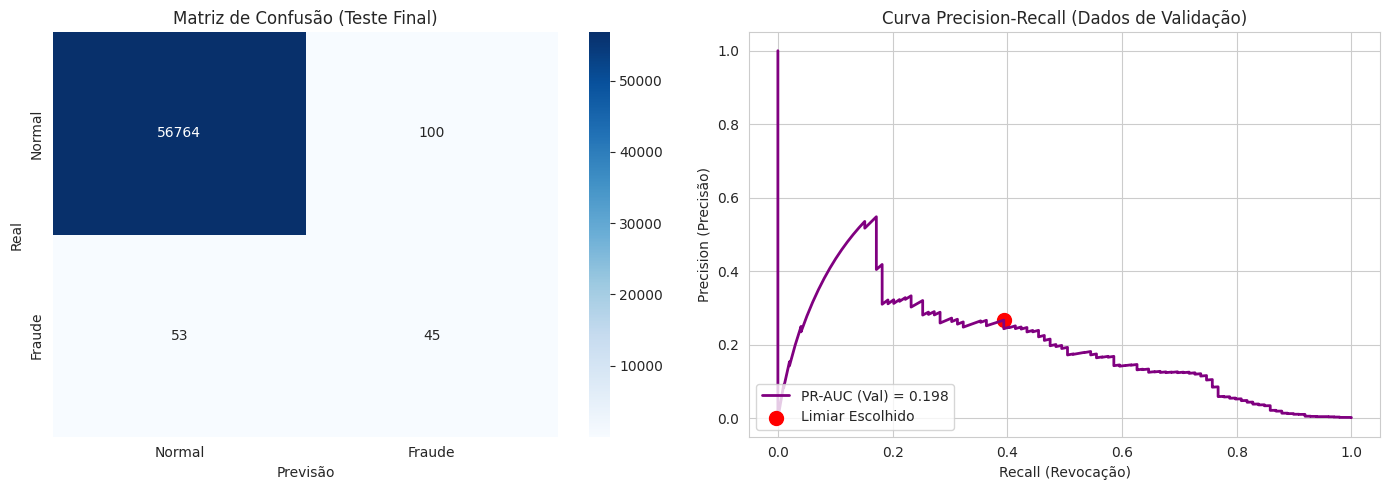


Fim do processamento. Métricas robustas aplicadas com sucesso!


In [1]:
# -*- coding: utf-8 -*-
"""
Script Otimizado para preparação e análise de dataset de Cartão de Crédito (Detecção de Fraude).
Base de dados adaptada para o padrão: Time, V1-V28, Amount, Class
Arquitetura: Simulação de Aprendizado Federado (Isolation Forest)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import random

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve)

# Fixar sementes para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

set_seed(42)

# Configurações de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("\n--- 1. Carregamento dos Dados ---\n")
caminho_csv = '/content/drive/MyDrive/Mestrado Cesar/Base de Dados/creditcard/creditcard.csv'

try:
    from google.colab import drive
    drive.mount('/content/drive')

    print(f"Tentando carregar '{caminho_csv}'...")
    df = pd.read_csv(caminho_csv)
    print("Arquivo carregado com sucesso!")
    print(f"Formato do dataset (Linhas, Colunas): {df.shape}")
    print("-" * 50)
except Exception as e:
    print(f"Aviso: Não foi possível carregar o arquivo original. Detalhe: {e}")
    # Usando dados simulados apenas para evitar que o script quebre se o arquivo não existir
    print("\n--- GERANDO DADOS SIMULADOS PARA DEMONSTRAÇÃO ---")
    n_samples = 15000
    df = pd.DataFrame(np.random.randn(n_samples, 28), columns=[f'V{i}' for i in range(1, 29)])
    df['Time'] = np.random.uniform(0, 172792, n_samples)
    df['Amount'] = np.abs(np.random.randn(n_samples)) * 100
    # Injetando anomalias (~0.5%)
    df['Class'] = np.random.choice([0, 1], size=n_samples, p=[0.995, 0.005])

print("\n--- 2. Limpeza de Colunas e Tratamento ---\n")

# Neste dataset (PCA), geralmente não há colunas categóricas como no PaySim.
# A coluna 'Time' pode ser vista como ruído para modelos baseados em distância/anomalia,
# pois é um contador incremental. Vamos removê-la para melhorar a detecção.
colunas_para_remover = ['Time']
df = df.drop(columns=[col for col in colunas_para_remover if col in df.columns])

print(f"As colunas {colunas_para_remover} foram removidas para evitar ruído.")

# Tratamento de Nulos crítico para ML
if df.isnull().sum().sum() > 0:
    print("Tratando valores nulos...")
    df = df.dropna(subset=['Class']) # Remove linhas sem a variável alvo
    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].median())

print("\n--- 3. Criação de Novas Variáveis (Engenharia de Features) ---\n")

# 1. amount_log: Suaviza a variação extrema dos valores de transação monetária.
# Útil pois 'Amount' no dataset original é a única variável não transformada por PCA.
if 'Amount' in df.columns:
    df['Amount'] = df['Amount'].apply(lambda x: max(x, 0)) # Proteção para log1p
    df['amount_log'] = np.log1p(df['Amount'])
    df = df.drop(columns=['Amount'])
    print("Variável 'amount_log' criada e 'Amount' original removida com sucesso.")
print("-" * 50)

print("\n--- 4. Preparando Dados para Machine Learning ---\n")

df_ml = df.copy()

# Separando X (Features) e y (Alvo)
X = df_ml.drop(columns=['Class'])
y = df_ml['Class']

# Divisão Correta: 60% Treino, 20% Validação, 20% Teste
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Dados divididos! Treino: {X_train.shape[0]}, Validação: {X_val.shape[0]}, Teste: {X_test.shape[0]}")

# Escalonamento Robusto: Vital para o Isolation Forest não dar peso excessivo a valores anômalos
print("Aplicando RobustScaler para normalizar as grandezas numéricas...")
scaler = RobustScaler()
# O escalonador SÓ PODE ver os dados de treinamento
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convertendo de volta para DataFrame por praticidade
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\n--- 5. Simulação de Aprendizado Federado (FL) ---\n")
NUM_CLIENTES = 3
print(f"Simulando ambiente com {NUM_CLIENTES} clientes (silos de dados).")

# Divisão dos dados de treino entre os "clientes"
tamanho_chunk = len(X_train) // NUM_CLIENTES
clientes_X = [X_train.iloc[i * tamanho_chunk : (i + 1) * tamanho_chunk] for i in range(NUM_CLIENTES)]

modelos_locais = []
tempos_treinamento = []

print("\nIniciando Treinamento Local (Isolation Forest) nos clientes...")
for i in range(NUM_CLIENTES):
    inicio_treino = time.time()

    # IsolationForest OTIMIZADO:
    # Contaminação 'auto' permite que a floresta foque na estrutura intrínseca dos dados
    modelo_local = IsolationForest(
        n_estimators=150,
        max_samples=0.8,
        contamination='auto',
        n_jobs=-1,
        random_state=42+i
    )

    # Cliente treina apenas com sua fatia de dados
    modelo_local.fit(clientes_X[i])
    fim_treino = time.time()

    modelos_locais.append(modelo_local)
    tempos_treinamento.append(fim_treino - inicio_treino)
    print(f"-> Cliente {i+1} treinado em {fim_treino - inicio_treino:.2f} segundos.")

print("\n--- 6. Agregação Federada e Otimização de Limiar ---")

class ModeloFederado:
    def __init__(self, modelos_locais):
        self.modelos_locais = modelos_locais

    def decision_function(self, X):
        # Média dos escores de anomalia de todos os clientes locais
        escores = np.zeros(X.shape[0])
        for modelo in self.modelos_locais:
            escores += modelo.decision_function(X)
        return escores / len(self.modelos_locais)

modelo_global = ModeloFederado(modelos_locais)

# ESTRATÉGIA CORRIGIDA: Encontrar o melhor limiar no conjunto de VALIDAÇÃO
print("\nOtimizando o limiar de decisão via Curva PR no conjunto de VALIDAÇÃO (Sem Data Leakage)...")
# Invertemos o sinal: Valores MAIORES = maior probabilidade de fraude
y_scores_val = -modelo_global.decision_function(X_val)

# Calculando precisão e recall para vários limiares possíveis usando a Validação
precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores_val)

# Calculando F1-Score para cada limiar (evitando divisão por zero)
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls),
                      out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

# O melhor limiar é aquele que maximiza o F1-Score na Validação
melhor_indice = np.argmax(f1_scores)
if melhor_indice < len(thresholds):
    limiar_otimizado = thresholds[melhor_indice]
else:
    # Prevenção contra vetor vazio
    limiar_otimizado = np.percentile(y_scores_val, 99)

print(f"Limiar matemático otimizado (F1 Máximo na Validação): {limiar_otimizado:.4f}")

print("\n--- 7. Inferência no Servidor Global (Teste Real) ---")
inicio_inferencia = time.time()

# Aplicando os escores estritamente na base de TESTE
y_scores_test = -modelo_global.decision_function(X_test)

# Classificando baseado no limiar otimizado, sem que o modelo tenha visto os dados
y_pred = (y_scores_test >= limiar_otimizado).astype(int)

fim_inferencia = time.time()
tempo_inferencia = fim_inferencia - inicio_inferencia

print("\n--- 8. Resultados Globais Pós-Otimização ---\n")

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_scores_test)
pr_auc = average_precision_score(y_test, y_scores_test)

print(">> MÉTRICAS DE QUALIDADE DO MODELO (ISOLATION FOREST):")
print(f"Acurácia Geral      : {acc * 100:.4f}%")
print(f"Precisão (Precision): {prec * 100:.4f}%")
print(f"Revocação (Recall)  : {rec * 100:.4f}%")
print(f"F1-Score            : {f1 * 100:.4f}%")
print(f"ROC-AUC             : {roc_auc:.4f}")
print(f"PR-AUC              : {pr_auc:.4f}")

tps = len(X_test) / tempo_inferencia if tempo_inferencia > 0 else float('inf')
print("\n>> MÉTRICAS DE RENDIMENTO TÉCNICO (THROUGHPUT):")
print(f"Amostras Processadas   : {len(X_test)} transações")
print(f"Tempo Total de Infe.   : {tempo_inferencia:.4f} segundos")
print(f"Rendimento (Throughput): {tps:.2f} transações por segundo\n")

# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de Confusão (Aplicada sobre os dados de Teste)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'])
axes[0].set_title('Matriz de Confusão (Teste Final)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Previsão')

# 2. Curva Precision-Recall (Do conjunto de Validação, onde o limiar foi escolhido)
axes[1].plot(recalls, precisions, color='purple', lw=2, label=f'PR-AUC (Val) = {average_precision_score(y_val, y_scores_val):.3f}')
# Proteção caso arrays estejam vazios ou melhor_indice fora dos limites
if len(recalls) > 0 and len(precisions) > 0 and melhor_indice < len(recalls):
    axes[1].scatter(recalls[melhor_indice], precisions[melhor_indice], color='red', s=100, label='Limiar Escolhido')
axes[1].set_xlabel('Recall (Revocação)')
axes[1].set_ylabel('Precision (Precisão)')
axes[1].set_title('Curva Precision-Recall (Dados de Validação)')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\nFim do processamento. Métricas robustas aplicadas com sucesso!")